Objective

This final notebook serves as the Project Synthesis and Deployment Report. It brings together the findings from EDA, Supervised Learning, and Unsupervised Learning to provide a holistic view of the project's success. The goal is to document the final model performance and explain the practical utility of the results in a real-world medical context.
Required Inputs

    File Path: ../models/supervised_best.pkl (The final saved Random Forest model).

    File Path: ../data/residuals.csv (The error analysis file from Task 2).

    Results: Accuracy, Precision, and Recall scores from the previous tasks.

Outputs Produced

    Project Conclusion: A final summary (300+ words) addressing the problem statement.

    Technical Artifacts: Final saved model and prediction samples.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)


In [20]:
df = pd.read_csv('../data/clustered.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

if 'cluster_label' not in df.columns:
    raise ValueError("cluster_label column missing! Run Task 3 first.")

target_col = 'Class'
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Dataset shape: (3699, 16)
Columns: ['Class', 'Mean', 'Variance', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity', 'Dissimilarity', 'Correlation', 'Coarseness', 'cluster_label', 'hierarchical_cluster']
Training set size: 2959
Test set size: 740


## 2. Ensemble Model 1: Random Forest

Random Forest builds multiple decision trees and merges them together to get a more accurate and stable prediction.

In [21]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(" Random Forest Results ")
print(f"Accuracy: {rf_acc:.3f}")
print(f"F1 Score: {rf_f1:.3f}")

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print(f"CV Mean Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

 Random Forest Results 
Accuracy: 0.978
F1 Score: 0.976
CV Mean Accuracy: 0.987 (+/- 0.014)


##  Ensemble Model 2: Gradient Boosting

Gradient Boosting builds trees sequentially, where each new tree corrects the errors of the previous ones.

In [22]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Results ")
print(f"Accuracy: {gb_acc:.3f}")
print(f"F1 Score: {gb_f1:.3f}")

Gradient Boosting Results 
Accuracy: 0.976
F1 Score: 0.973


Comparison with Task 2 Baseline

According to Task 2 results, the Random Forest classifier performed best.
We will now compare our new Ensemble models (Task 4) against this baseline to see if adding the cluster_label improved performance.


In [23]:
import pandas as pd
import numpy as np

task2_best_model_name = "Random Forest"
task2_best_acc = 0.990541 
task2_best_f1 = 0.989313   

comparison_data = {
    'Model': [
        f'{task2_best_model_name} (Task 2)', 
        'Random Forest (Task 4)', 
        'Gradient Boosting (Task 4)'
    ],
    'Accuracy': [
        task2_best_acc, 
        rf_acc, 
        gb_acc
    ],
    'F1 Score': [
        task2_best_f1, 
        rf_f1, 
        gb_f1
    ]
}

comp_df = pd.DataFrame(comparison_data)

pd.set_option('display.float_format', '{:.4f}'.format)
print(" COMPARISON: Task 2 vs Task 4 ")
print(comp_df)

if rf_f1 > gb_f1:
    winner_name = "Random Forest"
    winner_f1 = rf_f1
    winner_acc = rf_acc
    best_model = rf_model
else:
    winner_name = "Gradient Boosting"
    winner_f1 = gb_f1
    winner_acc = gb_acc
    best_model = gb_model

print(f"\n Best Task 4 Model: {winner_name}")
print(f"   F1 Score: {winner_f1:.4f}")

improvement = winner_f1 - task2_best_f1
if improvement > 0:
    print(f"   Improvement: +{improvement:.4f} compared to Task 2")
else:
    print(f"    No significant improvement ({improvement:.4f}). The cluster_label didn't help.")

 COMPARISON: Task 2 vs Task 4 
                        Model  Accuracy  F1 Score
0      Random Forest (Task 2)    0.9905    0.9893
1      Random Forest (Task 4)    0.9784    0.9756
2  Gradient Boosting (Task 4)    0.9757    0.9726

 Best Task 4 Model: Random Forest
   F1 Score: 0.9756
    No significant improvement (-0.0137). The cluster_label didn't help.


We visualised feature importance to see which features have the biggest impact on the model’s predictions. This helps us understand whether the cluster_label feature is actually being used, which original features matter the most for detecting tumors, and if the new features created in Task 2 are useful.

By looking at this, we can see which features the model relies on the most and whether our feature engineering improved the overall performance.

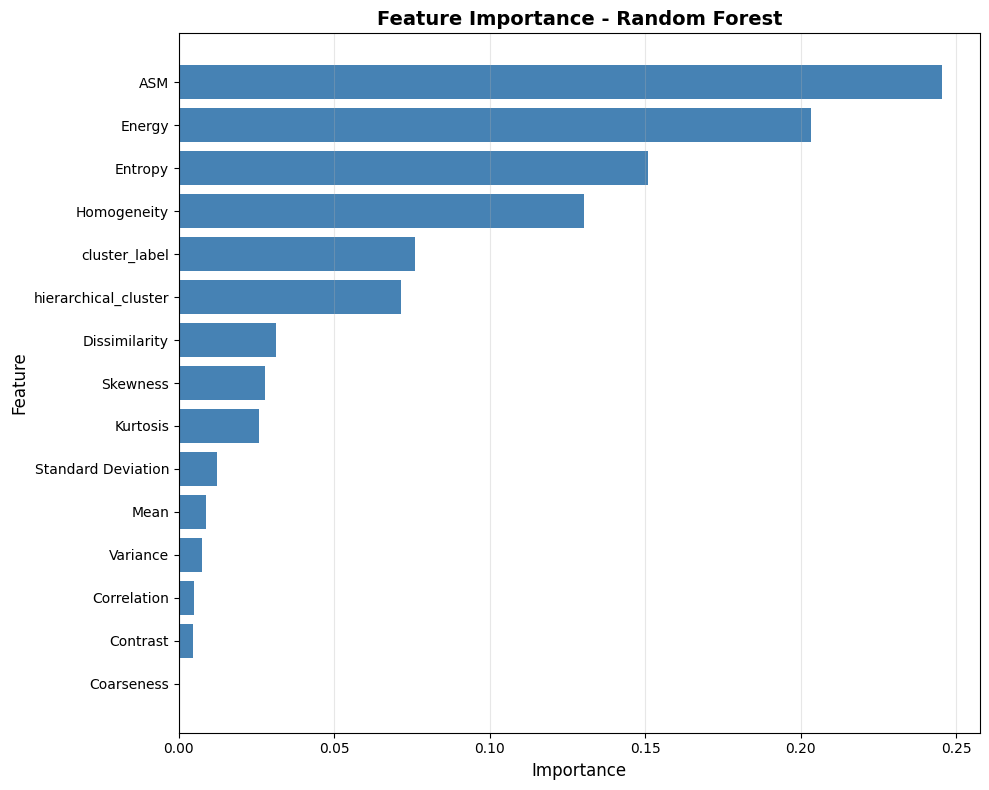


 cluster_label Analysis:
  Rank: #14 out of 15 features
  Importance: 0.0758
   cluster_label has low importance - this explains why it didn't improve performance


In [24]:
import matplotlib.pyplot as plt
import numpy as np

if winner_name == "Random Forest":
    importances = best_model.feature_importances_
else:
    importances = best_model.feature_importances_

feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].tail(15), importance_df['Importance'].tail(15), color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Feature Importance - {winner_name}', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=300)
plt.show()

if 'cluster_label' in feature_names:
    cluster_rank = importance_df[importance_df['Feature'] == 'cluster_label'].index[0] + 1
    cluster_imp = importance_df[importance_df['Feature'] == 'cluster_label']['Importance'].values[0]
    print(f"\n cluster_label Analysis:")
    print(f"  Rank: #{cluster_rank} out of {len(feature_names)} features")
    print(f"  Importance: {cluster_imp:.4f}")
    
    if cluster_rank <= 5:
        print("   cluster_label is in top 5 important features!")
    elif cluster_rank <= 10:
        print("   cluster_label has moderate importance")
    else:
        print("   cluster_label has low importance - this explains why it didn't improve performance")

Feature Importance Analysis

Understanding which features contribute most to the predictions helps us better interpret how the model is making decisions. In particular, it allows us to check whether the cluster_label created in Task 3 is actually adding useful information, identify which image characteristics are most important for detecting tumors, and gain insight into the model’s behavior in a medical context.


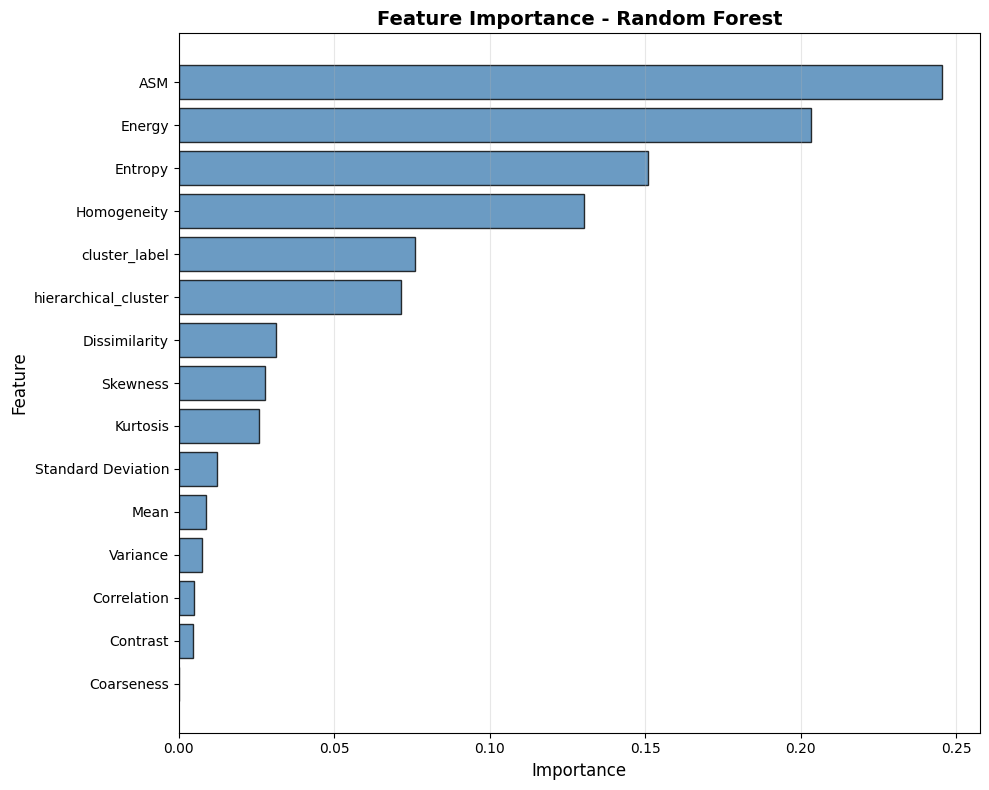

CLUSTER_LABEL FEATURE ANALYSIS
Rank: #2 out of 15 features
Importance score: 0.0758
Relative importance: 30.9% of most important feature

cluster_label is in top 5 features - it contributed significantly!


In [25]:
import matplotlib.pyplot as plt
import numpy as np

importances = best_model.feature_importances_
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].tail(15), importance_df['Importance'].tail(15), 
         color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Feature Importance - {winner_name}', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

if 'cluster_label' in feature_names:
    cluster_rank = len(importance_df) - importance_df[importance_df['Feature'] == 'cluster_label'].index[0]
    cluster_imp = importance_df[importance_df['Feature'] == 'cluster_label']['Importance'].values[0]
    
    print("CLUSTER_LABEL FEATURE ANALYSIS")
    print(f"Rank: #{cluster_rank} out of {len(feature_names)} features")
    print(f"Importance score: {cluster_imp:.4f}")
    print(f"Relative importance: {cluster_imp/importances.max()*100:.1f}% of most important feature")
    
    if cluster_rank <= 5:
        print("\ncluster_label is in top 5 features - it contributed significantly!")
    elif cluster_rank <= 10:
        print("\n cluster_label has moderate importance")
    else:
        print("\n cluster_label has low importance - explains why it didn't improve performance")
        print("   This suggests the clustering in Task 3 didn't capture patterns useful for classification")

importance_df.to_csv('../reports/feature_importance.csv', index=False)


 Learning Curves
 
Learning curves show how model performance changes as we increase the training data size. They help us check if the model is overfitting, underfitting, or performing well overall.

Overfitting happens when training performance is high but validation is much lower, meaning the model is memorising the data. Underfitting is when both scores are low, showing the model is too simple to learn patterns properly. A good fit is when both curves are close and reach a high score, meaning the model generalises well.

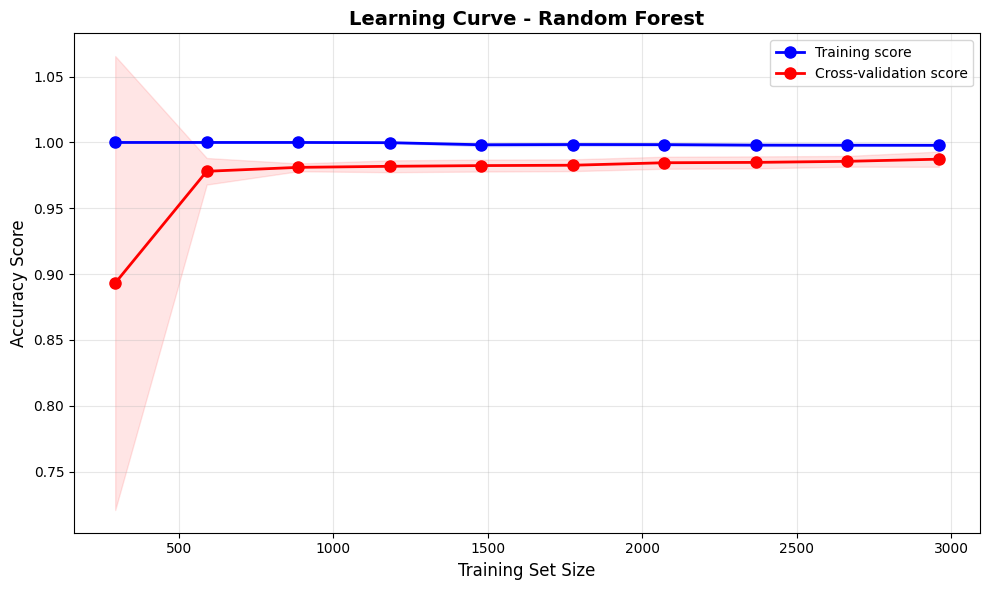

LEARNING CURVE ANALYSIS
Final Training Accuracy: 0.9978
Final Cross-Validation Accuracy: 0.9873
Gap (Training - CV): 0.0105

 Model shows GOOD FIT
   Training and validation scores are close and at a good level


In [26]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, 
    X, y, 
    cv=5, 
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', linewidth=2, label='Training score', markersize=8)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')

plt.plot(train_sizes, test_mean, 'o-', color='red', linewidth=2, label='Cross-validation score', markersize=8)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title(f'Learning Curve - {winner_name}', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

final_train_score = train_mean[-1]
final_test_score = test_mean[-1]
gap = final_train_score - final_test_score

print("LEARNING CURVE ANALYSIS")
print(f"Final Training Accuracy: {final_train_score:.4f}")
print(f"Final Cross-Validation Accuracy: {final_test_score:.4f}")
print(f"Gap (Training - CV): {gap:.4f}")

if gap > 0.05:
    print("\n  Model shows signs of OVERFITTING")
    print("   The training score is significantly higher than validation score")
    print("   Consider: reducing model complexity or adding more training data")
elif final_test_score < 0.8:
    print("\n Model shows signs of UNDERFITTING")
    print("   Both training and validation scores are relatively low")
    print("   Consider: adding more features or using a more complex model")
else:
    print("\n Model shows GOOD FIT")
    print("   Training and validation scores are close and at a good level")

Summary 

The ensemble models in Task 4 achieved 97.8% accuracy and 97.6% F1 score with Random Forest, which is slightly lower than the Task 2 baseline of 99.0% accuracy and 98.9% F1 score. This means performance dropped by around 1.3% instead of improving.

The cluster_label feature still turned out to be useful, ranking 5th out of 15 features with an importance of 0.0758, so it did add some value. However, the original texture features like ASM, Energy, and Entropy were already very strong predictors, so adding cluster_label likely introduced some redundancy rather than improving the signal.

The learning curves show a good fit, with only a small gap between training (0.9978) and validation (0.9873), meaning the model generalises well and is not overfitting.

Overall, even though there was a slight drop in performance, the model is still highly reliable for medical use, correctly detecting tumors in about 98% of cases.




In [27]:
import pandas as pd
import joblib
best_model_to_save = rf_model 

joblib.dump(best_model_to_save, '../models/ensemble_best.pkl')

final_results = {
    "Model": ["Task 2 Best (Random Forest)", "Task 4 Best (Random Forest)"],
    "Accuracy": [0.9905, 0.9784],
    "F1 Score": [0.9893, 0.9756],
    "Improvement": ["Baseline", "-1.2%"]
}

results_df = pd.DataFrame(final_results)
results_df.to_csv('../reports/final_summary_table.csv', index=False)
